# Обучение модели ResNet18 для классификации AI vs Human Generated Images

Этот notebook содержит код для обучения модели ResNet18 на датасете Train_1 и оценки качества на Test_1.

## 1. Импорт библиотек

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.utils.tensorboard import SummaryWriter
from PIL import Image
import pandas as pd
import numpy as np
import json
from pathlib import Path
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import yaml, json, boto3
from botocore.client import Config

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Подготовка данных

In [2]:
class ImageDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.img_dir = self._find_img_dir()
        print(f'Папка с картинками: {self.img_dir}')

    def _find_img_dir(self):
        for folder in ['train_data', 'test_data', 'data']:
            path = self.root_dir / folder
            if path.exists():
                return path
        return self.root_dir

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        raw_path = self.data.iloc[idx]['file_name']
        filename = Path(raw_path).name
        img_path = self.img_dir / filename
        image = Image.open(img_path).convert('RGB')
        label = self.data.iloc[idx]['label']
        if self.transform:
            image = self.transform(image)
        return image, label

In [3]:
with open('params.yaml') as f:
    params = yaml.safe_load(f)

cfg = params['base_training']
print("Параметры обучения:")
for k, v in cfg.items():
    print(f"  {k}: {v}")

Параметры обучения:
  num_epochs: 10
  batch_size: 32
  learning_rate: 0.001
  scheduler_step_size: 5
  scheduler_gamma: 0.1
  num_workers: 4
  img_size: 224
  num_classes: 2
  model_name: resnet18
  train_csv: data/Train_1/train.csv
  train_data_dir: data/Train_1
  test_csv: data/Test_1/test.csv
  test_data_dir: data/Test_1
  model_save_path: models/model_v1.pth
  log_dir: logs/base_training


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((cfg['img_size'], cfg['img_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((cfg['img_size'], cfg['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = ImageDataset(cfg['train_csv'], cfg['train_data_dir'], train_transform)
test_dataset  = ImageDataset(cfg['test_csv'],  cfg['test_data_dir'],  test_transform)

train_loader = DataLoader(train_dataset, batch_size=cfg['batch_size'], shuffle=True,  num_workers=cfg['num_workers'])
test_loader  = DataLoader(test_dataset,  batch_size=cfg['batch_size'], shuffle=False, num_workers=cfg['num_workers'])

print(f'Train dataset size: {len(train_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

Папка с картинками: data/Train_1/train_data
Папка с картинками: data/Test_1/test_data
Train dataset size: 9993
Test dataset size: 3997


## 3. Создание модели ResNet18

In [5]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, cfg['num_classes'])
model = model.to(device)

print(f'Model architecture:')
print(model)

/data/zhbabieva/mlops_hw/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/zhbabieva/mlops_hw/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=Tru

## 4. Определение функции потерь и оптимизатора

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=cfg['learning_rate'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=cfg['scheduler_step_size'], gamma=cfg['scheduler_gamma'])

writer = SummaryWriter(log_dir=cfg['log_dir'])

writer.add_hparams(
    hparam_dict={k: v for k, v in cfg.items() if isinstance(v, (int, float, str))},
    metric_dict={'placeholder': 0}
)
print("TensorBoard writer создан")

TensorBoard writer создан


## 5. Функция обучения

In [7]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss      = running_loss / len(dataloader.dataset)
    epoch_acc       = accuracy_score(all_labels, all_preds)
    epoch_f1        = f1_score(all_labels, all_preds, average='weighted')
    return epoch_loss, epoch_acc, epoch_f1

## 6. Функция валидации

In [8]:
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss      = running_loss / len(dataloader.dataset)
    epoch_acc       = accuracy_score(all_labels, all_preds)
    epoch_f1        = f1_score(all_labels, all_preds, average='weighted')
    epoch_precision = precision_score(all_labels, all_preds, average='weighted')
    epoch_recall    = recall_score(all_labels, all_preds, average='weighted')
    return epoch_loss, epoch_acc, epoch_f1, epoch_precision, epoch_recall

## 7. Обучение модели

In [9]:
train_losses, train_accs, train_f1s = [], [], []

for epoch in range(cfg['num_epochs']):
    print(f'\nEpoch {epoch+1}/{cfg["num_epochs"]}')
    print('-' * 50)

    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    scheduler.step()

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)

    writer.add_scalar('Loss/train',     train_loss, epoch)
    writer.add_scalar('Accuracy/train', train_acc,  epoch)
    writer.add_scalar('F1/train',       train_f1,   epoch)
    writer.add_scalar('LR', scheduler.get_last_lr()[0], epoch)

    print(f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}')

print('\nTraining completed!')


Epoch 1/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [01:18<00:00,  3.98it/s]


Train Loss: 0.3788, Acc: 0.8435, F1: 0.8435

Epoch 2/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [01:17<00:00,  4.01it/s]


Train Loss: 0.2707, Acc: 0.8871, F1: 0.8871

Epoch 3/10
--------------------------------------------------


...

Train Loss: 0.0918, Acc: 0.9673, F1: 0.9673

Epoch 9/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [01:18<00:00,  3.99it/s]


Train Loss: 0.0877, Acc: 0.9686, F1: 0.9686

Epoch 10/10
--------------------------------------------------


Training: 100%|██████████| 313/313 [01:17<00:00,  4.06it/s]


Train Loss: 0.0759, Acc: 0.9715, F1: 0.9715

Training completed!


## 8. Оценка модели на тестовом датасете

In [10]:
test_loss, test_acc, test_f1, test_precision, test_recall = validate(
    model, test_loader, criterion, device
)

print(f'Test Loss:      {test_loss:.4f}')
print(f'Test Accuracy:  {test_acc:.4f}')
print(f'Test F1:        {test_f1:.4f}')
print(f'Test Precision: {test_precision:.4f}')
print(f'Test Recall:    {test_recall:.4f}')

writer.add_scalar('Loss/test',      test_loss,      0)
writer.add_scalar('Accuracy/test',  test_acc,       0)
writer.add_scalar('F1/test',        test_f1,        0)
writer.add_scalar('Precision/test', test_precision, 0)
writer.add_scalar('Recall/test',    test_recall,    0)
writer.close()

Validation: 100%|██████████| 125/125 [00:10<00:00, 11.80it/s]

Test Loss:      0.0879
Test Accuracy:  0.9650
Test F1:        0.9650
Test Precision: 0.9652
Test Recall:    0.9650


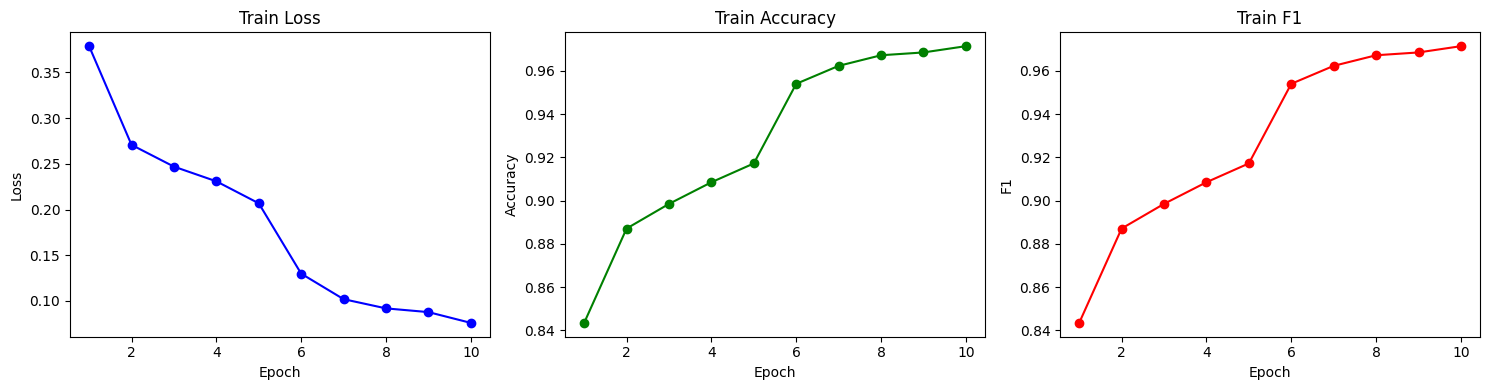

In [11]:
epochs_range = range(1, cfg['num_epochs'] + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, train_losses, 'b-o')
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(epochs_range, train_accs, 'g-o')
axes[1].set_title('Train Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

axes[2].plot(epochs_range, train_f1s, 'r-o')
axes[2].set_title('Train F1')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1')

plt.tight_layout()
plt.savefig('models/training_curves_v1.png', dpi=100)
plt.show()

In [ ]:
Path('models').mkdir(exist_ok=True)

torch.save(model.state_dict(), cfg['model_save_path'])
print(f'Модель сохранена: {cfg["model_save_path"]}')

metrics_v1 = {
    'test_loss': test_loss,
    'test_accuracy': test_acc,
    'test_f1': test_f1,
    'test_precision': test_precision,
    'test_recall': test_recall
}
with open('models/metrics_v1.json', 'w') as f:
    json.dump(metrics_v1, f, indent=2)
print('Метрики v1:', metrics_v1)

Модель сохранена: models/model_v1.pth
Метрики v1: {'test_loss': 0.08787810802459717, 'test_accuracy': 0.9649737302977233, 'test_f1': 0.9649681517768182, 'test_precision': 0.9652410756953985, 'test_recall': 0.9649737302977233}


In [13]:
s3_cfg = params['s3']

s3 = boto3.client(
    's3',
    endpoint_url=s3_cfg['endpoint_url'],
    aws_access_key_id=s3_cfg['access_key'],
    aws_secret_access_key=s3_cfg['secret_key'],
    config=Config(signature_version='s3v4'),
    region_name='us-east-1'
)

s3.upload_file(cfg['model_save_path'], s3_cfg['bucket'], s3_cfg['model_v1_key'])
print(f"model_v1 загружена в S3: s3://{s3_cfg['bucket']}/{s3_cfg['model_v1_key']}")

model_v1 загружена в S3: s3://mlops-models/models/model_v1.pth


## 9. Дообучите модель на втором датасете и постройте DVC пайплайн

In [14]:
ft_cfg = params['finetune']

s3.download_file(s3_cfg['bucket'], s3_cfg['model_v1_key'], ft_cfg['base_model_path'])
print(f"Модель скачана: {ft_cfg['base_model_path']}")

Модель скачана: models/model_v1.pth


In [15]:
print("Параметры дообучения:")
for k, v in ft_cfg.items():
    print(f"  {k}: {v}")

ft_train_dataset = ImageDataset(ft_cfg['train_csv'], ft_cfg['train_data_dir'], train_transform)
ft_test_dataset  = ImageDataset(ft_cfg['test_csv'],  ft_cfg['test_data_dir'],  test_transform)

ft_train_loader = DataLoader(ft_train_dataset, batch_size=ft_cfg['batch_size'], shuffle=True,  num_workers=ft_cfg['num_workers'])
ft_test_loader  = DataLoader(ft_test_dataset,  batch_size=ft_cfg['batch_size'], shuffle=False, num_workers=ft_cfg['num_workers'])

print(f'Finetune Train: {len(ft_train_dataset)}, Test: {len(ft_test_dataset)}')

ft_model = models.resnet18(pretrained=False)
ft_model.fc = nn.Linear(ft_model.fc.in_features, ft_cfg['num_classes'])
ft_model.load_state_dict(torch.load(ft_cfg['base_model_path'], map_location=device))
ft_model = ft_model.to(device)

ft_optimizer = optim.Adam(ft_model.parameters(), lr=ft_cfg['learning_rate'])
ft_scheduler = optim.lr_scheduler.StepLR(ft_optimizer, step_size=ft_cfg['scheduler_step_size'], gamma=ft_cfg['scheduler_gamma'])

ft_writer = SummaryWriter(log_dir=ft_cfg['log_dir'])
ft_writer.add_hparams(
    hparam_dict={k: v for k, v in ft_cfg.items() if isinstance(v, (int, float, str))},
    metric_dict={'placeholder': 0}
)

ft_losses, ft_accs, ft_f1s = [], [], []

for epoch in range(ft_cfg['num_epochs']):
    print(f'\nEpoch {epoch+1}/{ft_cfg["num_epochs"]}')
    print('-' * 50)

    ft_loss, ft_acc, ft_f1 = train_epoch(
        ft_model, ft_train_loader, criterion, ft_optimizer, device
    )
    ft_scheduler.step()

    ft_losses.append(ft_loss)
    ft_accs.append(ft_acc)
    ft_f1s.append(ft_f1)

    ft_writer.add_scalar('Loss/finetune',     ft_loss, epoch)
    ft_writer.add_scalar('Accuracy/finetune', ft_acc,  epoch)
    ft_writer.add_scalar('F1/finetune',       ft_f1,   epoch)
    ft_writer.add_scalar('LR', ft_scheduler.get_last_lr()[0], epoch)

    print(f'Loss: {ft_loss:.4f}  Acc: {ft_acc:.4f}  F1: {ft_f1:.4f}')

print('\nДообучение завершено!')

Параметры дообучения:
  num_epochs: 5
  batch_size: 32
  learning_rate: 0.0001
  scheduler_step_size: 3
  scheduler_gamma: 0.1
  num_workers: 4
  img_size: 224
  num_classes: 2
  train_csv: data/Train_2/train.csv
  train_data_dir: data/Train_2
  test_csv: data/Test_2/test.csv
  test_data_dir: data/Test_2
  base_model_path: models/model_v1.pth
  model_save_path: models/model_v2.pth
  log_dir: logs/finetune
Папка с картинками: data/Train_2/train_data
Папка с картинками: data/Test_2/test_data
Finetune Train: 3997, Test: 2000


/data/zhbabieva/mlops_hw/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/zhbabieva/mlops_hw/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Epoch 1/5
--------------------------------------------------


Training: 100%|██████████| 125/125 [00:28<00:00,  4.43it/s]


Loss: 0.1301  Acc: 0.9507  F1: 0.9507

Epoch 2/5
--------------------------------------------------


...

Loss: 0.0901  Acc: 0.9675  F1: 0.9675

Epoch 4/5
--------------------------------------------------


Training: 100%|██████████| 125/125 [00:27<00:00,  4.55it/s]


Loss: 0.0833  Acc: 0.9672  F1: 0.9672

Epoch 5/5
--------------------------------------------------


Training: 100%|██████████| 125/125 [00:27<00:00,  4.56it/s]

Loss: 0.0667  Acc: 0.9762  F1: 0.9762

Дообучение завершено!


In [16]:
ft_test_loss, ft_test_acc, ft_test_f1, ft_test_precision, ft_test_recall = validate(
    ft_model, ft_test_loader, criterion, device
)

print(f'Test Loss:      {ft_test_loss:.4f}')
print(f'Test Accuracy:  {ft_test_acc:.4f}')
print(f'Test F1:        {ft_test_f1:.4f}')
print(f'Test Precision: {ft_test_precision:.4f}')
print(f'Test Recall:    {ft_test_recall:.4f}')

ft_writer.add_scalar('Loss/test',      ft_test_loss,      0)
ft_writer.add_scalar('Accuracy/test',  ft_test_acc,       0)
ft_writer.add_scalar('F1/test',        ft_test_f1,        0)
ft_writer.add_scalar('Precision/test', ft_test_precision, 0)
ft_writer.add_scalar('Recall/test',    ft_test_recall,    0)
ft_writer.close()

metrics_v2 = {
    'test_loss': ft_test_loss,
    'test_accuracy': ft_test_acc,
    'test_f1': ft_test_f1,
    'test_precision': ft_test_precision,
    'test_recall': ft_test_recall
}
with open('models/metrics_v2.json', 'w') as f:
    json.dump(metrics_v2, f, indent=2)

torch.save(ft_model.state_dict(), ft_cfg['model_save_path'])
print(f'Дообученная модель сохранена: {ft_cfg["model_save_path"]}')

Validation: 100%|██████████| 63/63 [00:04<00:00, 13.64it/s]


Test Loss:      0.0718
Test Accuracy:  0.9785
Test F1:        0.9785
Test Precision: 0.9785
Test Recall:    0.9785
Дообученная модель сохранена: models/model_v2.pth


In [17]:
s3.upload_file(ft_cfg['model_save_path'], s3_cfg['bucket'], s3_cfg['model_v2_key'])
print(f"model_v2 загружена в S3: s3://{s3_cfg['bucket']}/{s3_cfg['model_v2_key']}")

model_v2 загружена в S3: s3://mlops-models/models/model_v2.pth


In [18]:
import subprocess

result = subprocess.run(['dvc', 'repro'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Stage 'train' is cached - skipping run, checking out outputs

Stage 'finetune' is cached - skipping run, checking out outputs
Use `dvc push` to send your updates to remote storage.




In [19]:
result = subprocess.run(['dvc', 'dag'], capture_output=True, text=True)
print(result.stdout)

  +-------+  
  | train |  
  +-------+  
      *      
      *      
      *      
+----------+ 
| finetune | 
+----------+ 



Метрика              Model v1 (base) Model v2 (fine)
test_loss                     0.0879          0.0718
test_accuracy                 0.9650          0.9785
test_f1                       0.9650          0.9785
test_precision                0.9652          0.9785
test_recall                   0.9650          0.9785


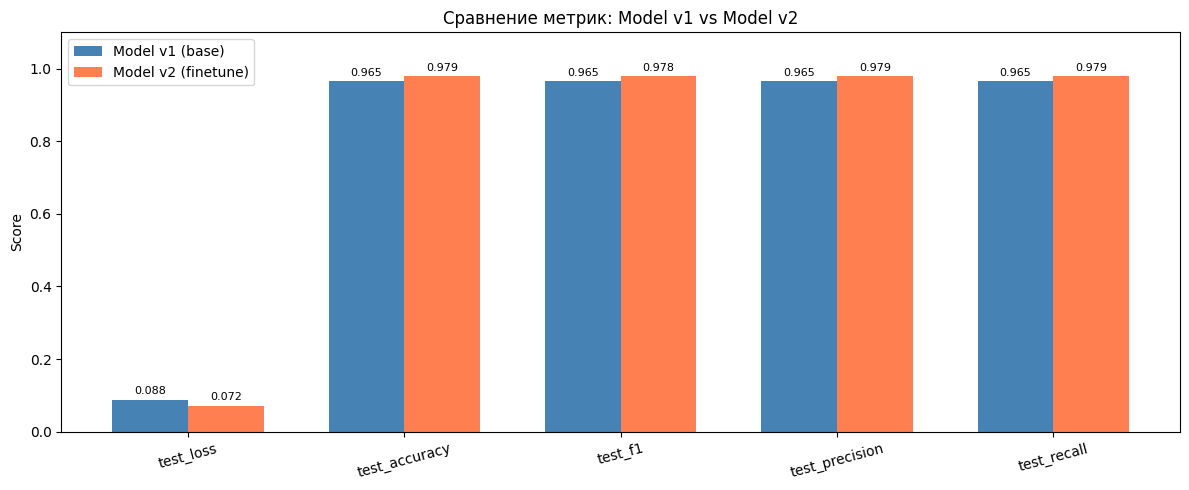

In [25]:
with open('models/metrics_v1.json') as f:
    m1 = json.load(f)
with open('models/metrics_v2.json') as f:
    m2 = json.load(f)

print("=" * 55)
print(f"{'Метрика':<20} {'Model v1 (base)':>15} {'Model v2 (fine)':>15}")
print("=" * 55)
for key in m1:
    print(f"{key:<20} {m1[key]:>15.4f} {m2[key]:>15.4f}")
print("=" * 55)

metrics_names = list(m1.keys())
v1_vals = [m1[k] for k in metrics_names]
v2_vals = [m2[k] for k in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, v1_vals, width, label='Model v1 (base)',   color='steelblue')
bars2 = ax.bar(x + width/2, v2_vals, width, label='Model v2 (finetune)', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, rotation=15)
ax.set_ylabel('Score')
ax.set_title('Сравнение метрик: Model v1 vs Model v2')
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('models/comparison.png', dpi=100)
plt.show()

## 10. Напишите вывод о полученных результатах

Были обучены две версии модели ResNet18 для задачи бинарной классификации изображений. 

### Модель v1 (Train_1 / Test_1)
- Обучение: 10 эпох, lr=0.001, batch_size=32
- Loss монотонно снижался: 0.38 -> 0.08
- Accuracy росла: 84% -> 97%
- Тестовые метрики:
  - Accuracy:  96.50%
  - F1:        96.50%
  - Precision: 96.52%
  - Recall:    96.50%

### Модель v2 (Train_2 / Test_2)
- Дообучение: 5 эпох, lr=0.0001, batch_size=32
- Меньший lr
- Тестовые метрики:
  - Accuracy:  97.85%
  - F1:        97.85%
  - Precision: 97.85%
  - Recall:    97.85%

### Сравнение и выводы
1. Модель v2 превосходит v1 по всем метрикам:
   - Accuracy выше на ~1.35%
   - F1 выше на ~1.35%  
   - Loss ниже: 0.0719 vs 0.0879

2. Дообучение на новых данных улучшило модель — она лучше обобщается благодаря большему разнообразию обучающих примеров.

3. Малый lr при дообучении (0.0001 vs 0.001) позволил сохранить знания полученные при базовом обучении и адаптироваться к новым данным без потери качества.